In [ ]:
import pandas as pd
import matplotlib as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [14]:
X_train = pd.read_csv("../data/processed/X_train.csv", index_col=0)
y_train = pd.read_csv("../data/processed/y_train.csv", index_col=0)

X_test = pd.read_csv("../data/processed/X_test.csv", index_col=0)
y_test = pd.read_csv("../data/processed/y_test.csv", index_col=0)

In [15]:
X_train.sample(5)

,WHO_Region,Country,Age,Gender,Smoking_Status,Cigarettes_Per_Day,Years_Smoking,Secondhand_Smoke,Family_History,Occupational_Hazard,...,Recurrent_Infections,Swallowing_Difficulty,Finger_Clubbing,Cancer_Type,NSCLC_Subtype,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment
1306,Western Pacific,Australia,51,Female,Current Smoker,12,30,No,No,No,...,No,No,No,NSCLC,Adenocarcinoma,Stage I,0.7,No,LDCT Screening,Targeted Therapy
163,South-East Asia,Bangladesh,62,Male,Former Smoker,3,12,No,No,No,...,No,No,No,NSCLC,Adenocarcinoma,Stage II,3.5,No,Bronchoscopy,Surgery + Chemotherapy
612,Americas,Venezuela,73,Male,Never Smoked,0,0,No,No,Yes,...,Yes,No,No,NSCLC,Squamous Cell,Stage I,2.4,No,LDCT Screening,Surgery
1312,Europe,France,70,Male,Current Smoker,33,48,Yes,No,No,...,No,No,No,NSCLC,Adenocarcinoma,Stage IV,6.4,Yes,Biopsy,Targeted Therapy
137,Americas,Canada,74,Female,Current Smoker,5,32,No,No,Yes,...,No,No,No,NSCLC,Adenocarcinoma,Stage III,4.8,No,PET Scan,Chemo + Radiation


In [10]:
# define numeric and categorical columns
num_cols = ['Age', 'Cigarettes_Per_Day', 'Years_Smoking',
            'BMI', 'Tumor_Size_cm']

cat_cols = ['WHO_Region','Country', 'Gender', 'Smoking_Status',
            'Secondhand_Smoke', 'Family_History', 'Occupational_Hazard',
            'Air_Pollution_Exposure', 'Alcohol_Use', 'Exercise_Frequency',
            'Chronic_Lung_Disease', 'Asbestos_Exposure', 'Radon_Exposure',
            'Previous_Cancer_History', 'Genetic_Mutation', 'Coughing',
            'Shortness_of_Breath', 'Chest_Pain', 'Coughing_Blood', 'Fatigue',
            'Weight_Loss', 'Wheezing', 'Recurrent_Infections', 
            'Swallowing_Difficulty', 'Finger_Clubbing', 'Cancer_Type', 
            'NSCLC_Subtype', 'Cancer_Stage', 'Metastasis', 'Diagnosis_Method', 
            'Treatment']


# Baseline Model: RandomForest without hypertuning

In [16]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

rf = RandomForestClassifier(n_estimators=100,
                            class_weight='balanced',
                            random_state=0,
                            n_jobs=-1)

model_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf)
])

In [18]:
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)

print(f"Random Forests Performance:")
print(f"F1 Score: {f1_score(y_test, y_pred, 
                            pos_label='Yes'):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, 
                                      model_rf.predict_proba(X_test)[:, 1]):.4f}\n")

c:\Users\Jaeden Capinig\Documents\DPP-Projekt\.venv\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forests Performance:
F1 Score: 0.6759
ROC-AUC Score: 0.8508



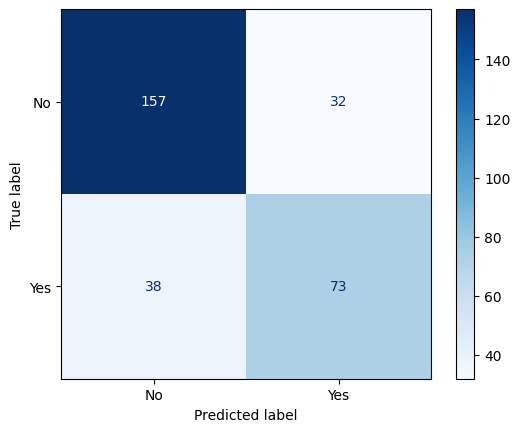

In [30]:
# Confusion Matrix
from turtle import title


cm = confusion_matrix(y_test, 
                      y_pred, 
                      labels=['No', 'Yes'])

disp = ConfusionMatrixDisplay(cm, 
                              display_labels=['No', 'Yes']).plot(cmap='Blues')
